In [1]:
import sys
import os
import psycopg2
from dotenv import load_dotenv
import QuantLib as ql


sys.path.append(os.path.abspath(".."))
from utils.black_scholes import get_implied_vol

load_dotenv()

url = os.getenv("DATABASE_URL")

In [2]:
conn = psycopg2.connect(url, sslmode="require")
cur = conn.cursor()

In [3]:
postfix_list = [
    "CD6E", #04-29
]
expiry_date = ql.Date(29, 4, 2026)
eval_date = ql.Date(16, 4, 2026)
option_type = "call"

ticker = "SR"
min_strike = 270
max_strike = 370
strike_step = 10

strike = min_strike
tickers = []
while strike < max_strike:
    for postfix in postfix_list:
        option_ticker = ticker + str(strike) + postfix
        tickers.append(option_ticker)
    strike += strike_step
print(tickers)

['SR270CD6E', 'SR280CD6E', 'SR290CD6E', 'SR300CD6E', 'SR310CD6E', 'SR320CD6E', 'SR330CD6E', 'SR340CD6E', 'SR350CD6E', 'SR360CD6E']


In [4]:
query = """
SELECT DISTINCT ON (ticker)
    ticker,
    bids,
    asks
FROM orderbooks
WHERE ticker = ANY(%s)
ORDER BY ticker, timestamp DESC;
"""

cur.execute(query, (tickers,))
rows = cur.fetchall()

In [5]:
rows

[('SR270CD6E',
  [{'price': 55.59, 'quantity': 800}],
  [{'price': 57.04, 'quantity': 800}]),
 ('SR280CD6E',
  [{'price': 47.37, 'quantity': 800}],
  [{'price': 48.81, 'quantity': 800}]),
 ('SR290CD6E',
  [{'price': 32.34, 'quantity': 2500}, {'price': 10.15, 'quantity': 10}],
  [{'price': 36.83, 'quantity': 5500}]),
 ('SR300CD6E',
  [{'price': 23.66, 'quantity': 800},
   {'price': 23.16, 'quantity': 1600},
   {'price': 0.02, 'quantity': 10}],
  [{'price': 24.0, 'quantity': 800},
   {'price': 24.6, 'quantity': 800},
   {'price': 25.06, 'quantity': 800}]),
 ('SR310CD6E',
  [{'price': 13.81, 'quantity': 800}],
  [{'price': 13.98, 'quantity': 800}]),
 ('SR320CD6E',
  [{'price': 5.3, 'quantity': 100},
   {'price': 5.04, 'quantity': 800},
   {'price': 5.0, 'quantity': 1043},
   {'price': 4.98, 'quantity': 800},
   {'price': 4.5, 'quantity': 33267}],
  [{'price': 6.57, 'quantity': 2500},
   {'price': 6.58, 'quantity': 800},
   {'price': 6.9, 'quantity': 10},
   {'price': 6.94, 'quantity': 800

In [6]:
def compute_mid_price(bids, asks):
    best_bid = None
    best_ask = None
    
    if bids:
        best_bid = max(bids, key=lambda x: x["price"])["price"]
    if asks:
        best_ask = min(asks, key=lambda x: x["price"])["price"]

    if best_bid is not None and best_ask is not None:
        return (best_bid + best_ask) / 2
    return best_bid or best_ask

In [7]:
result = []

for ticker, bids, asks in rows:
    mid = compute_mid_price(bids, asks)

    result.append({
        "ticker": ticker,
        "mid": mid,
    })
result

[{'ticker': 'SR270CD6E', 'mid': 56.315},
 {'ticker': 'SR280CD6E', 'mid': 48.09},
 {'ticker': 'SR290CD6E', 'mid': 34.585},
 {'ticker': 'SR300CD6E', 'mid': 23.83},
 {'ticker': 'SR310CD6E', 'mid': 13.895},
 {'ticker': 'SR320CD6E', 'mid': 5.9350000000000005},
 {'ticker': 'SR330CD6E', 'mid': 0.225},
 {'ticker': 'SR340CD6E', 'mid': 0.25},
 {'ticker': 'SR350CD6E', 'mid': 0.08},
 {'ticker': 'SR360CD6E', 'mid': 0.06}]

In [8]:
data = result
spot_price = 322
risk_free_rate = 0.15

result = []

for r in data:
    ticker = r["ticker"]
    mid = r["mid"]
    strike = int(r["ticker"][2:5])


    if strike is None:
        continue

    try:
        iv = get_implied_vol(
            market_price=mid,
            spot_price=spot_price,
            strike_price=strike,
            risk_free_rate=risk_free_rate,
            expiry_date=expiry_date,
            eval_date=eval_date,
            option_type=option_type
            )
    except Exception as e:
        iv = None
        print(e)
        

    result.append({
        "strike": strike,
        "mid": mid,
        "iv": iv,
        "ticker": ticker
    })
result

[{'strike': 270,
  'mid': 56.315,
  'iv': 0.8361935359444099,
  'ticker': 'SR270CD6E'},
 {'strike': 280,
  'mid': 48.09,
  'iv': 0.8380835135178011,
  'ticker': 'SR280CD6E'},
 {'strike': 290,
  'mid': 34.585,
  'iv': 0.43446591797980855,
  'ticker': 'SR290CD6E'},
 {'strike': 300,
  'mid': 23.83,
  'iv': 0.23308953835004204,
  'ticker': 'SR300CD6E'},
 {'strike': 310,
  'mid': 13.895,
  'iv': 0.14991994343914386,
  'ticker': 'SR310CD6E'},
 {'strike': 320,
  'mid': 5.9350000000000005,
  'iv': 0.1575958173568068,
  'ticker': 'SR320CD6E'},
 {'strike': 330,
  'mid': 0.225,
  'iv': 0.07885930359498008,
  'ticker': 'SR330CD6E'},
 {'strike': 340,
  'mid': 0.25,
  'iv': 0.16456575697513728,
  'ticker': 'SR340CD6E'},
 {'strike': 350,
  'mid': 0.08,
  'iv': 0.19674103995757505,
  'ticker': 'SR350CD6E'},
 {'strike': 360, 'mid': 0.06, 'iv': 0.2460975196718297, 'ticker': 'SR360CD6E'}]

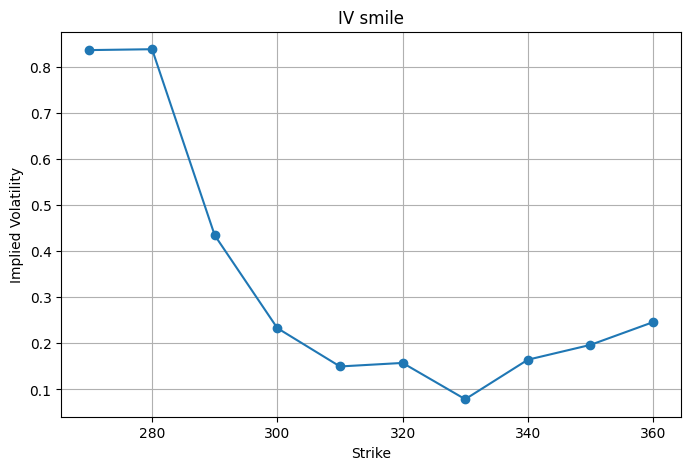

In [11]:
import matplotlib.pyplot as plt
data = result
strikes = [x["strike"] for x in data]
ivs = [x["iv"] for x in data]

plt.figure(figsize=(8,5))
plt.plot(strikes, ivs, marker="o")

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("IV smile")
plt.grid(True)

plt.show()